In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans


import sys, os
sys.path.append(os.path.abspath(".."))

import seaborn as sns


In [3]:
# Load training data
data = pd.read_csv('../data/claims_train.csv')

In [9]:
df = data.copy()

# Cap exposure
df["Exposure"] = df["Exposure"].clip(upper=1.0)

# Targets
y_rate = (df["ClaimNb"] / df["Exposure"]).astype(float)
w_expo = df["Exposure"].astype(float)

# Feature engineering
df["LogBonus"] = np.log(df["BonusMalus"])
df["LogDensity"] = np.log(df["Density"])


numeric_cols = ["VehPower", "VehAge", "DrivAge", "LogBonus", "LogDensity"]

# Scale for PCA
X_scaled = StandardScaler().fit_transform(df[numeric_cols])





In [10]:

# Numeric only PCA
pca_num = PCA().fit(X_scaled)
expl_num = pca_num.explained_variance_ratio_
cum_num = np.cumsum(expl_num)


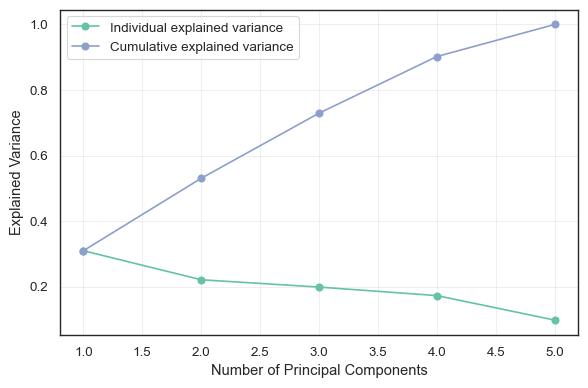

In [11]:

sns.set_theme(style="white", context="paper", font_scale=1.1)

pcs_num = np.arange(1, len(expl_num) + 1)

plt.figure(figsize=(6, 4))

# Individual explained variance
plt.plot(pcs_num, expl_num, marker='o', label='Individual explained variance',color=sns.color_palette("Set2")[0])

# Cumulative explained variance
plt.plot(pcs_num,cum_num, marker='o', label='Cumulative explained variance', color=sns.color_palette("Set2")[2])

plt.xlabel('Number of Principal Components')
plt.ylabel('Explained Variance')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.show()


PCA: Variation trade off vs pc's

for 2 PCs - 0.531 variance explained 
k=2: silhouette=0.402
k=3: silhouette=0.373
k=4: silhouette=0.330
k=5: silhouette=0.320
k=6: silhouette=0.333
for 3 PCs - 0.729 variance explained 
k=2: silhouette=0.316
k=3: silhouette=0.264
k=4: silhouette=0.291
k=5: silhouette=0.267
k=6: silhouette=0.235
for 4 PCs - 0.902 variance explained 
k=2: silhouette=0.258
k=3: silhouette=0.217
k=4: silhouette=0.231
k=5: silhouette=0.219
k=6: silhouette=0.210


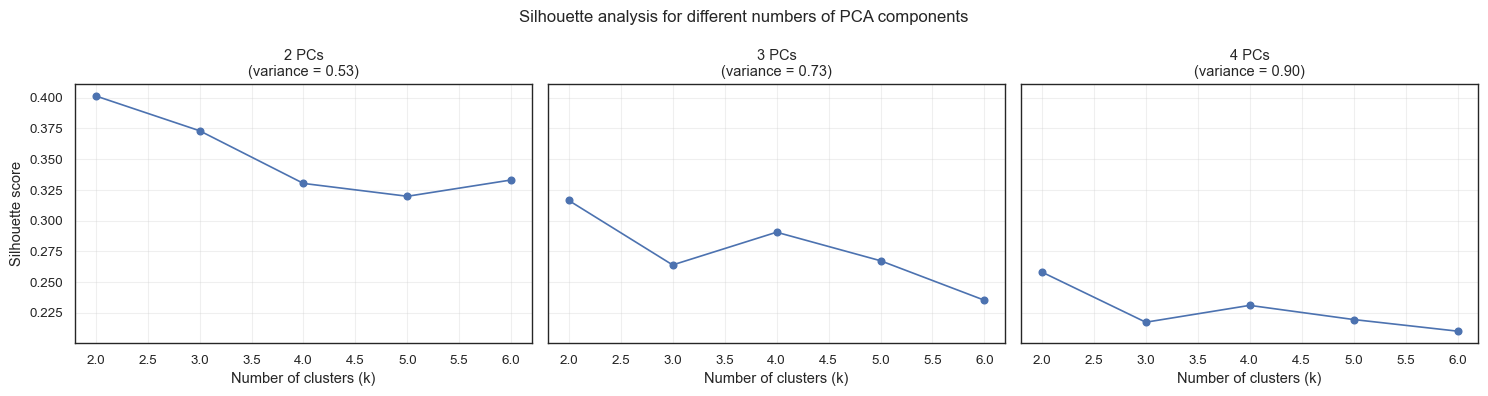

In [15]:
rng = np.random.default_rng(42)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, n in zip(axes, [2, 3, 4]):
    # PCA on scaled numeric data
    pca = PCA(n_components=n, random_state=42)
    X_pca = pca.fit_transform(X_scaled)

    # Variance explained
    var = pca.explained_variance_ratio_.sum()

    # Subsample
    sample_size = min(5000, len(X_pca))
    idx = rng.choice(len(X_pca), size=sample_size, replace=False)

    print(f"for {n} PCs - {var:.3f} variance explained ")

    silhouette_scores = []
    K = [2, 3, 4, 5, 6]

    for k in K:
        labels = KMeans(n_clusters=k, n_init=10, random_state=42).fit_predict(X_pca)
        score = silhouette_score(X_pca[idx], labels[idx])
        silhouette_scores.append(score)
        print(f"k={k}: silhouette={score:.3f}")

    # plotting
    ax.plot(K, silhouette_scores, marker="o")
    ax.set_title(f"{n} PCs\n(variance = {var:.2f})")
    ax.set_xlabel("Number of clusters (k)")
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("Silhouette score")

fig.suptitle("Silhouette analysis for different numbers of PCA components", fontsize=12)
plt.tight_layout()
plt.show()


Choose between more variance explained, and higher silhouette meaning more partitioning in data by clustering


we choose 2pc, k=3

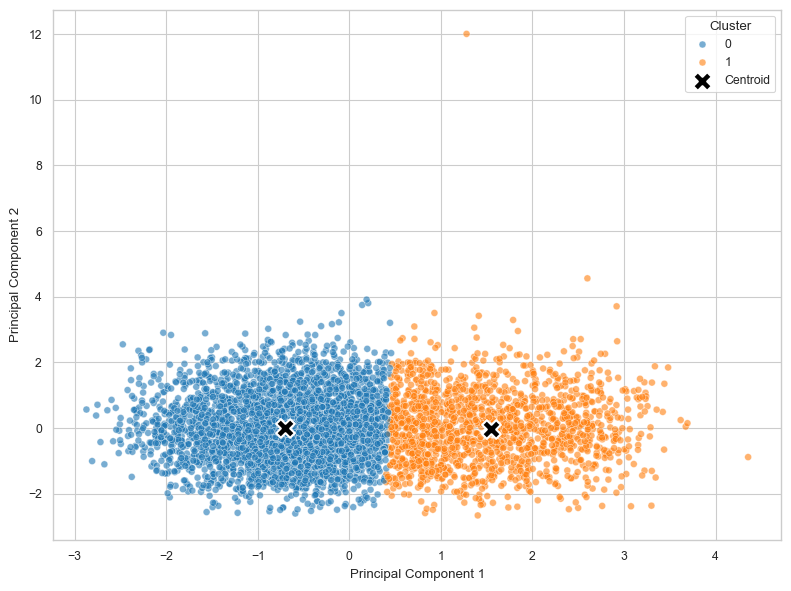

In [16]:
# Seaborn settings
sns.set_theme(style="whitegrid", context="paper", palette="tab10")

# PCA (2 components)
pca = PCA(n_components=2, random_state=42)
X_pca_2d = pca.fit_transform(X_scaled)

# KMeans (k = 2)
kmeans = KMeans(n_clusters=2, n_init=20, random_state=42)
labels = kmeans.fit_predict(X_pca_2d)

# Fixed colors for clusters across ALL plots
cluster_order = sorted(np.unique(labels))   # [0, 1, 2]
base = sns.color_palette("tab10", n_colors=len(cluster_order))
palette_map = {c: base[i] for i, c in enumerate(cluster_order)}

# Subsample for plotting
rng = np.random.default_rng(42)
sample_size = min(5000, len(X_pca_2d))
idx = rng.choice(len(X_pca_2d), size=sample_size, replace=False)

# plotting
plot_df = pd.DataFrame(X_pca_2d[idx],columns=["PC1", "PC2"])
plot_df["Cluster"] = labels[idx].astype(int)

centroids_df = pd.DataFrame(kmeans.cluster_centers_,columns=["PC1", "PC2"])

# --- Plot ---
plt.figure(figsize=(8, 6))

ax = sns.scatterplot(data=plot_df,x="PC1",y="PC2",hue="Cluster",hue_order=cluster_order,palette=palette_map,alpha=0.6,s=25)

plt.scatter(centroids_df["PC1"], centroids_df["PC2"], c="black", s=180, marker="X", edgecolors="white", linewidths=1.5, label="Centroid")

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.legend(title="Cluster")
plt.tight_layout()
plt.show()


In [19]:
loadings = pd.DataFrame(pca.components_.T, columns=[f"PC{i+1}" for i in range(pca.n_components_)],index=df[numeric_cols].columns)
    

for i in range(pca.n_components_):
    pc = (loadings.iloc[:, i].abs().sort_values(ascending=False).head(5))
    print(f"\nTop 5 absolute loadings for PC{i+1}:")
    print(pc)


Top 5 absolute loadings for PC1:
LogBonus      0.692632
DrivAge       0.668627
LogDensity    0.192987
VehAge        0.137741
VehPower      0.130313
Name: PC1, dtype: float64

Top 5 absolute loadings for PC2:
VehAge        0.709404
LogDensity    0.697488
VehPower      0.083979
DrivAge       0.054527
LogBonus      0.015173
Name: PC2, dtype: float64


In [23]:
# cluster-level claim frequency
cluster_claim_rate = (data.groupby("Cluster").apply(lambda g: g["ClaimNb"].sum() / g["Exposure"].sum()))

summary = data.groupby("Cluster")[["DrivAge","VehAge","VehPower","BonusMalus","Density"]].mean().round(2)
summary["Claim_rate"] = cluster_claim_rate
summary["Count"] = data["Cluster"].value_counts().sort_index()
print(summary)

         DrivAge  VehAge  VehPower  BonusMalus  Density  Claim_rate   Count
Cluster                                                                    
0          51.34    6.63      6.61       51.55  1509.63    0.088388  374011
1          32.53    7.96      6.11       77.99  2432.58    0.135871  168399


/var/folders/tf/7fzgzx6j6p7dlmgznhxvzgn80000gn/T/ipykernel_61091/1284074926.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cluster_claim_rate = (data.groupby("Cluster").apply(lambda g: g["ClaimNb"].sum() / g["Exposure"].sum()))


/var/folders/tf/7fzgzx6j6p7dlmgznhxvzgn80000gn/T/ipykernel_61091/2912960630.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data, x="Cluster_str", y="Claim_rate", order=cluster_order_str, palette=palette_map_str, estimator=np.mean)


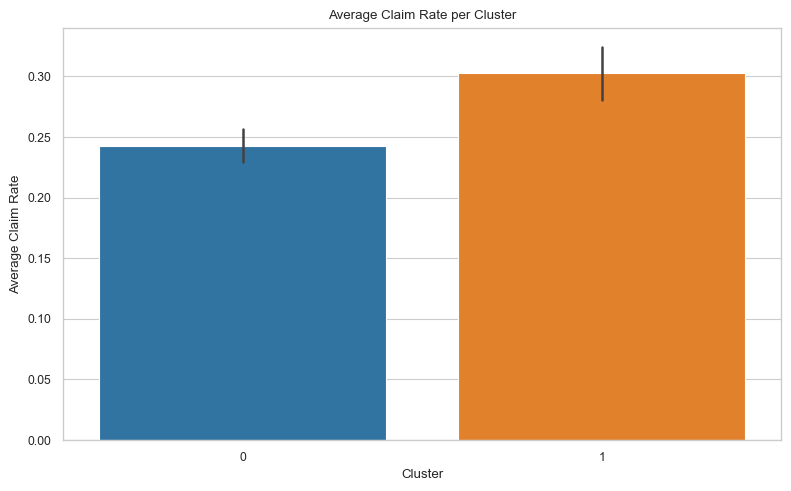

In [25]:
data["Cluster_str"] = data["Cluster"].astype(str)

cluster_order_str = sorted(data["Cluster_str"].unique(), key=int)

base = sns.color_palette("tab10", n_colors=len(cluster_order_str))
palette_map_str = {c: base[i] for i, c in enumerate(cluster_order_str)}


plt.figure(figsize=(8,5))
sns.barplot(data=data, x="Cluster_str", y="Claim_rate", order=cluster_order_str, palette=palette_map_str, estimator=np.mean)
plt.title("Average Claim Rate per Cluster")
plt.ylabel("Average Claim Rate")
plt.xlabel("Cluster")
plt.tight_layout()
plt.show()


meaning higher claim rate connected to high pc1 scores (which is dominated by logbonusmalus and driverage)

In [26]:
print("\nMost common Area per cluster:")
print(data.groupby("Cluster")["Area"].agg(lambda x: x.mode()[0]))
print("\nMost common Region per cluster:")
print(data.groupby("Cluster")["Region"].agg(lambda x: x.mode()[0]))
print("\nMost common Vehicle brand per cluster:")
print(data.groupby("Cluster")["VehBrand"].agg(lambda x: x.mode()[0]))
print("\nMost common Fuel Type per cluster:")
print(data.groupby("Cluster")["VehGas"].agg(lambda x: x.mode()[0]))



Most common Area per cluster:
Cluster
0    C
1    E
Name: Area, dtype: object

Most common Region per cluster:
Cluster
0    R24
1    R24
Name: Region, dtype: object

Most common Vehicle brand per cluster:
Cluster
0    B12
1     B1
Name: VehBrand, dtype: object

Most common Fuel Type per cluster:
Cluster
0    Regular
1    Regular
Name: VehGas, dtype: object
